# AAV9 -- putting the naive ground-truth F/J (built directly from the real target) to the test

`AAV9_profile_model.ipynb` (section 2/3b) builds a **naive** ground-truth additive+pairwise
profile directly from `aav9.csv`'s real `target` -- no model in the loop at all:

- `F_GT[a, i]` = mean `target` of every real sequence carrying amino acid `a` at position `i`,
  minus the dataset baseline (`target.mean()`).
- `J_naive[i, j, a, b]` = mean `target` of every real sequence carrying `(a at i) AND (b at j)`,
  minus the baseline and each position's own `F_GT` effect -- what's left over after the
  single-site effects are already accounted for. Cells with fewer than `min_support=5`
  supporting sequences are left undefined (too little data to trust the mean).

This is the most literal possible "ground truth" for this real dataset: it never leaves the
observed data, no MLP or regression is fit to anything. The question this notebook asks: **if
we rank all the real aav9 variants by `F_GT + J_naive`, do the 500 variants that come out on
top match the 500 real variants that actually have the highest `target`?** A profile can look
fine on aggregate correlation and still fail at exactly this, because correlation is dominated
by the bulk of the (mostly mediocre) library, while directed evolution only ever cares about
the extreme tail.


### Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from analysisV1 import AA_LABELS, pearson, plot_topk_recovery

num_positions   = 7
num_amino_acids = len(AA_LABELS)
assert num_amino_acids == 20


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the real aav9 dataset

In [2]:
df = pd.read_csv("aav9.csv")

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target     = df["target"].to_numpy()

print(f"{len(df):,} real aav9 variants")


68,776 real aav9 variants


### Build the naive ground-truth F/J directly from the real target

Exact same two functions as `AAV9_profile_model.ipynb` sections 2 and 3b -- reproduced here
so this notebook is self-contained. No fitting, no neural net: every entry is a plain group
mean over real sequences that happen to carry that amino acid (or amino-acid pair).


In [3]:
def F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions):
    """F_GT[a, i] = mean target of real sequences carrying amino acid a at position i,
    minus the dataset baseline."""
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    counts = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for aa in range(num_amino_acids):
            mask = seq_matrix[:, i] == aa
            counts[aa, i] = mask.sum()
            if mask.any():
                F[aa, i] = target[mask].mean() - baseline
    return F, counts


def J_groundtruth_naive(seq_matrix, target, F, baseline, num_amino_acids, num_positions, min_support=5):
    """J_naive[i, j, a, b] = mean target of real sequences carrying (a at i) AND (b at j),
    minus the baseline and each position's own F_GT effect. NaN where fewer than
    min_support sequences support the cell."""
    L, A = num_positions, num_amino_acids
    J = np.full((L, L, A, A), np.nan)
    support = np.zeros((L, L, A, A), dtype=int)

    position_masks = [[seq_matrix[:, i] == a for a in range(A)] for i in range(L)]

    for i in range(L):
        for j in range(i + 1, L):
            for a in range(A):
                mask_a = position_masks[i][a]
                if not mask_a.any():
                    continue
                for b in range(A):
                    mask = mask_a & position_masks[j][b]
                    n = int(mask.sum())
                    support[i, j, a, b] = support[j, i, b, a] = n
                    if n >= min_support:
                        val = target[mask].mean() - baseline - F[a, i] - F[b, j]
                        J[i, j, a, b] = J[j, i, b, a] = val
    return J, support


baseline = target.mean()
F_GT, F_counts = F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions)
J_naive, J_support = J_groundtruth_naive(seq_matrix, target, F_GT, baseline=baseline,
                                          num_amino_acids=num_amino_acids, num_positions=num_positions,
                                          min_support=5)

off_diag = ~np.eye(num_positions, dtype=bool)
print(f"F_GT: {np.isnan(F_GT).sum()} / {F_GT.size} (amino acid, position) cells have zero support")
print(f"J_naive: {(~np.isnan(J_naive)).sum():,} / {J_naive.size:,} cells filled "
      f"({np.isnan(J_naive[off_diag]).mean() * 100:.1f}% of off-diagonal cells still NaN, "
      f"median support {np.median(J_support[off_diag]):.0f} sequences/cell)")


F_GT: 0 / 140 (amino acid, position) cells have zero support
J_naive: 16,800 / 19,600 cells filled (0.0% of off-diagonal cells still NaN, median support 172 sequences/cell)


### Score every real variant with F_GT + J_naive

Same additive+pairwise convention as `Protocol.compute_score` elsewhere in the project:
`score(seq) = sum_i F[seq_i, i] + sum_{i<j} J[i, j, seq_i, seq_j]`. Undefined (NaN, too little
support) `J_naive` cells are filled with 0 -- "no evidence of an interaction" -- rather than
dropping those sequences, matching the `nan_to_num(..., nan=0.0)` convention already used when
`AAV9_profile_model.ipynb` exports its own J matrix.


In [4]:
def compute_FJ_score(seq_matrix, F, J):
    """(N, L) raw amino-acid indices -> (N,) additive+pairwise F+J score, same convention
    as Protocol.compute_score elsewhere in the project."""
    L = seq_matrix.shape[1]
    score = F[seq_matrix, np.arange(L)].sum(axis=1).astype(np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            score += J[i, j, seq_matrix[:, i], seq_matrix[:, j]]
    return score


F_GT_filled    = np.nan_to_num(F_GT, nan=0.0)
J_naive_filled = np.nan_to_num(J_naive, nan=0.0)

gt_score = compute_FJ_score(seq_matrix, F_GT_filled, J_naive_filled)

r_pearson  = pearson(target, gt_score)
r_spearman = spearmanr(target, gt_score).statistic
print(f"Across all {len(df):,} real variants: corr(target, F_GT/J_naive score) -- "
      f"Pearson r={r_pearson:.4f}   Spearman rho={r_spearman:.4f}")


Across all 68,776 real variants: corr(target, F_GT/J_naive score) -- Pearson r=0.8570   Spearman rho=0.8630


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Two DIFFERENT real top-500 sets, both drawn from the SAME full <code>aav9.csv</code> pool (all 68,776 real variants, no train/test split at this point in the notebook): <code>top_target_set</code> = top-500 ranked by real measured <code>target</code>; <code>top_score_set</code> = top-500 ranked by the naive <code>F_GT</code>/<code>J_naive</code> group-mean estimator (built directly from <code>target</code> itself, no model). Both sets are "real" and drawn from the identical pool, just ranked by a different criterion -- so their 28/500 (5.6%) overlap is a genuine empirical finding, not a tautology. Do not confuse either with the HELD-OUT (<code>idx_test</code>-only) top-500 introduced later in this notebook, or with the brute-force theoretical top-500s in <code>AAV_MLP_weights_recovery.ipynb</code>.
</div>

### Do the top-500 real variants (by actual target) also have the top-500 F_GT/J_naive score?

For every one of the 68,776 real variants, plot its real `target` (x-axis) against its
`F_GT`/`J_naive` score (y-axis), then color each point by whether it's in the top-500 of
`target`, the top-500 of the score, both, or neither. Note the two axes are NOT the same
quantity on the same scale (`target` is a single raw measurement; the score is a sum of
averaged deviations) -- so there's no meaningful "y = x" line here, unlike the real-vs-predicted
plots later in this notebook where both axes genuinely are log enrichment on the same scale.
This plot is purely about RANKING / set membership, not about the two values matching
numerically.


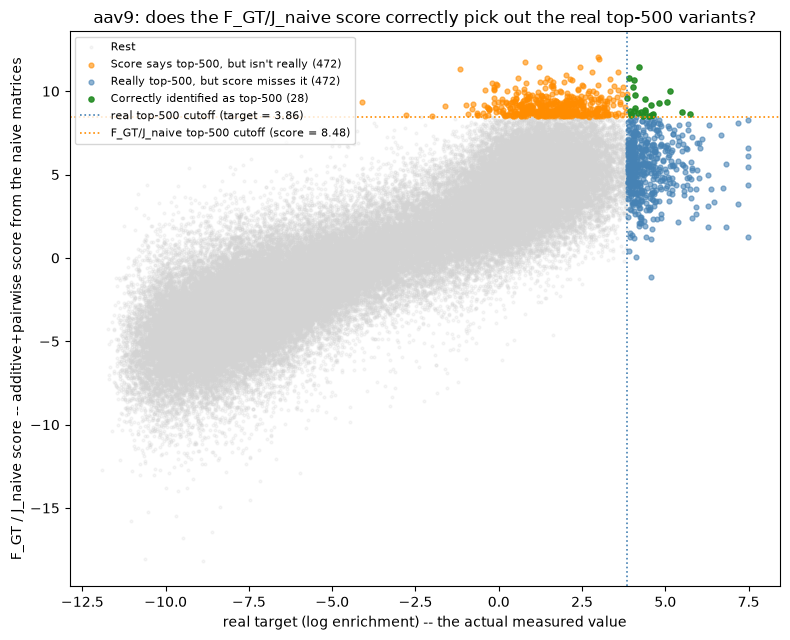

28/500 of the real top-500 variants (by target) are correctly identified by the F_GT/J_naive score's own top-500 (5.6%)


In [5]:
top_k = 500

top_target_set = set(np.argsort(-target)[:top_k].tolist())
top_score_set  = set(np.argsort(-gt_score)[:top_k].tolist())

recovered_idx = np.array(sorted(top_target_set & top_score_set))
missed_idx    = np.array(sorted(top_target_set - top_score_set))
falsepos_idx  = np.array(sorted(top_score_set - top_target_set))
rest_idx      = np.array(sorted(set(range(len(df))) - top_target_set - top_score_set))

thr_target = np.sort(target)[-top_k]
thr_score  = np.sort(gt_score)[-top_k]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(target[rest_idx],     gt_score[rest_idx],     s=4,  alpha=0.2, color="lightgray",
           label="Rest")
ax.scatter(target[falsepos_idx], gt_score[falsepos_idx], s=12, alpha=0.6, color="darkorange",
           label=f"Score says top-500, but isn't really ({len(falsepos_idx)})")
ax.scatter(target[missed_idx],   gt_score[missed_idx],   s=12, alpha=0.6, color="steelblue",
           label=f"Really top-500, but score misses it ({len(missed_idx)})")
ax.scatter(target[recovered_idx], gt_score[recovered_idx], s=14, alpha=0.9, color="forestgreen",
           label=f"Correctly identified as top-500 ({len(recovered_idx)})")

ax.axvline(thr_target, color="steelblue",  linestyle=":", lw=1.2,
           label=f"real top-{top_k} cutoff (target = {thr_target:.2f})")
ax.axhline(thr_score,  color="darkorange", linestyle=":", lw=1.2,
           label=f"F_GT/J_naive top-{top_k} cutoff (score = {thr_score:.2f})")

ax.set_xlabel("real target (log enrichment) -- the actual measured value")
ax.set_ylabel("F_GT / J_naive score -- additive+pairwise score from the naive matrices")
ax.set_title(f"aav9: does the F_GT/J_naive score correctly pick out the real top-{top_k} variants?")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

print(f"{len(recovered_idx)}/{top_k} of the real top-{top_k} variants (by target) are correctly "
      f"identified by the F_GT/J_naive score's own top-{top_k} "
      f"({100 * len(recovered_idx) / top_k:.1f}%)")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same two full-68,776-variant populations as the section above (real top-500 by <code>target</code>, real top-500 by <code>F_GT</code>/<code>J_naive</code> score), now with a NEW baseline added: <code>random500_full_idx</code> is 500 sequences chosen uniformly at random from the full <code>aav9.csv</code> (NOT selected on <code>target</code> at all) -- a statistical control, not a "top" of anything.
</div>

### Same selection-bias diagnostics as the MLP section, applied to the F_GT/J_naive score

Same two checks used later in this notebook for `model_mlp` (random-500 contrast, 20-bin
residual curve), applied here to the naive `F_GT`/`J_naive` score instead -- there's no
train/test split for a non-fitted score, so both checks run over the full 68,776-variant
dataset (`target` vs. `gt_score` directly). If the same regression-to-the-mean signature shows
up here too, that's evidence the pattern isn't specific to how `model_mlp` was trained -- it's a
more general consequence of comparing anything to a `target` that may itself be noisy.

One correction needed first: `F_GT`/`J_naive` are mean-centered by construction (`baseline =
target.mean()` was subtracted when building them), so `gt_score` sits near 0 on average while
`target` sits near `target.mean() ~= -3.96`. That ~4-point offset would make a raw "mean real
vs. mean score" comparison, or a `y = x` line, misleading -- it's a difference in zero-point
between the two quantities, not evidence of anything. `gt_score_abs = gt_score + baseline` adds
that back, putting the score on the same absolute scale as `target` (this shift doesn't affect
any ranking/precision numbers earlier in the notebook -- those only depend on relative order,
which a constant shift never changes).


In [44]:
gt_score_abs = gt_score + baseline  # same absolute scale as target -- see note above

top500_full_idx    = np.argsort(-target)[:top_k]
real_top500_full   = target[top500_full_idx]
score_top500_full  = gt_score_abs[top500_full_idx]
r_top500_full      = pearson(real_top500_full, score_top500_full)

rng_gt                = np.random.default_rng(0)
random500_full_idx    = rng_gt.choice(len(df), size=top_k, replace=False)
real_random500_full   = target[random500_full_idx]
score_random500_full  = gt_score_abs[random500_full_idx]
r_random500_full      = pearson(real_random500_full, score_random500_full)

print(f"Random {top_k} real variants (NOT selected on target): r={r_random500_full:.4f}   "
      f"mean real={real_random500_full.mean():.3f}   mean F_GT/J_naive estimate={score_random500_full.mean():.3f}")
print(f"Top-{top_k} real variants (selected on target):        r={r_top500_full:.4f}   "
      f"mean real={real_top500_full.mean():.3f}   mean F_GT/J_naive estimate={score_top500_full.mean():.3f}")


Random 500 real variants (NOT selected on target): r=0.8675   mean real=-3.938   mean F_GT/J_naive estimate=-3.938
Top-500 real variants (selected on target):        r=-0.0237   mean real=4.547   mean F_GT/J_naive estimate=1.634


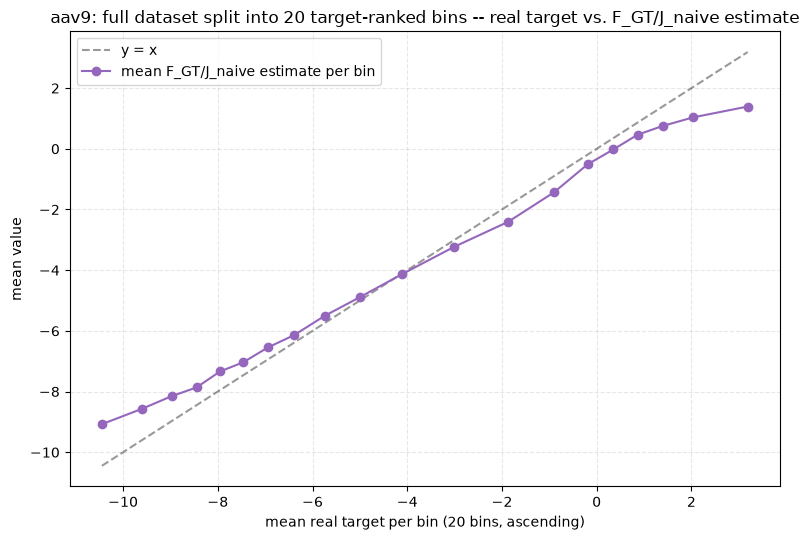

In [7]:
n_bins = 20
order      = np.argsort(target)
bins       = np.array_split(order, n_bins)
bin_real   = np.array([target[b].mean()       for b in bins])
bin_score  = np.array([gt_score_abs[b].mean() for b in bins])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(bin_real, bin_real, "k--", alpha=0.4, label="y = x")
ax.plot(bin_real, bin_score, "o-", color="tab:purple", label="mean F_GT/J_naive estimate per bin")
ax.set_xlabel(f"mean real target per bin ({n_bins} bins, ascending)"); ax.set_ylabel("mean value")
ax.set_title(f"aav9: full dataset split into {n_bins} target-ranked bins -- real target vs. F_GT/J_naive estimate")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout(); plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same real top-500-by-<code>target</code> (full 68,776-row <code>aav9.csv</code> pool) as the sections above, now viewed against the <code>F_GT</code>/<code>J_naive</code> score's distribution over that same full pool -- no new population introduced in this cell.
</div>

### Where do the real top-500 land in the F_GT/J_naive score's distribution over the whole real library?

Same style as `landscape_check` in `AAV_MLP_weights_recovery.ipynb`, but the background here is
the F_GT/J_naive score over the *real, measured* variants in `aav9.csv` (not an exhaustive scan
of the full theoretical sequence space -- we only have a real `target` to compare against for
variants that were actually measured).


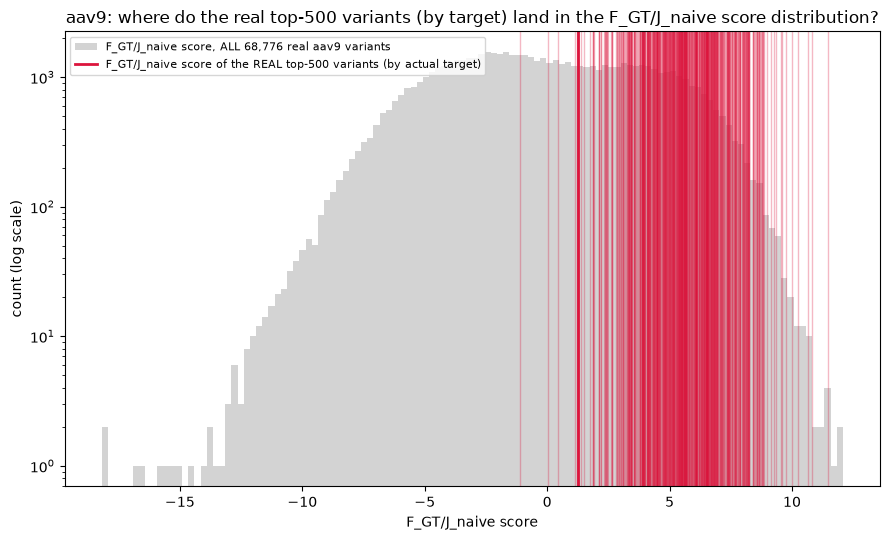

F_GT/J_naive-score percentile of the real top-500 variants (by target): median=90.20th   min=42.40th   max=100.00th
  37/500 land in the F_GT/J_naive score's own top 1%   257/500 land in its top 10%


In [8]:
top_target_idx       = np.argsort(-target)[:top_k]
score_of_top_target  = gt_score[top_target_idx]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(gt_score, bins=120, color="lightgray", label=f"F_GT/J_naive score, ALL {len(df):,} real aav9 variants")
for v in score_of_top_target:
    ax.axvline(v, color="crimson", alpha=0.3, lw=1)
ax.axvline(score_of_top_target[0], color="crimson", lw=2,
           label=f"F_GT/J_naive score of the REAL top-{top_k} variants (by actual target)")
ax.set_yscale("log")
ax.set_xlabel("F_GT/J_naive score"); ax.set_ylabel("count (log scale)")
ax.set_title(f"aav9: where do the real top-{top_k} variants (by target) land in the F_GT/J_naive score distribution?")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

score_order                = np.argsort(gt_score)  # ascending
percentile_of               = np.empty(len(df))
percentile_of[score_order]  = 100 * np.arange(len(df)) / (len(df) - 1)
pct                          = percentile_of[top_target_idx]

print(f"F_GT/J_naive-score percentile of the real top-{top_k} variants (by target): "
      f"median={np.median(pct):.2f}th   min={np.min(pct):.2f}th   max={np.max(pct):.2f}th")
print(f"  {int((pct >= 99).sum())}/{top_k} land in the F_GT/J_naive score's own top 1%   "
      f"{int((pct >= 90).sum())}/{top_k} land in its top 10%")


### Training a fresh ProfileMLP directly on aav9's real target

Everything above uses either the pre-computed `aav9_F_viab_mlp.npy`/`J_viab_mlp.npy` matrices or
a naive group-mean estimator -- neither one is an actual model making a genuine out-of-sample
prediction. This trains a fresh `ProfileMLP` (same architecture/training recipe as
`AAV_MLP_weights_recovery.ipynb`'s `run_dataset`: one-hot input, 128->64 hidden, BatchNorm +
Dropout + GELU, Adam with a warmup-cosine schedule, early stopping) directly on `aav9.csv`'s real
`target`, with a 50/50 train/test split (further split 85/15 train/val) -- so the comparison
below is a genuine held-out prediction, not a memorized fit.


In [9]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


class ProfileMLP(nnx.Module):
    """MLP over the one-hot encoded per-position sequence (L=7 x A=20 -> 140 indicator
    features) -> scalar predicted log enrichment. Same architecture used elsewhere in the
    project (AAV_MLP_weights_recovery.ipynb, AAV9_profile_model.ipynb)."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


JAX backend: gpu -- devices: [CudaDevice(id=0)]


train: 29,230  val: 5,158  test: 34,388



Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]


Training ProfileMLP:   0%|          | 1/300 [00:06<33:54,  6.81s/it]


Training ProfileMLP:   3%|▎         | 8/300 [00:06<03:05,  1.58it/s]


Training ProfileMLP:   4%|▍         | 13/300 [00:07<01:37,  2.93it/s]

...


Training ProfileMLP:  17%|█▋        | 50/300 [00:07<00:08, 28.21it/s]


Training ProfileMLP:  18%|█▊        | 55/300 [00:08<00:07, 31.36it/s]


Training ProfileMLP:  20%|██        | 60/300 [00:08<00:07, 33.28it/s]


Training ProfileMLP:  20%|██        | 61/300 [00:08<00:32,  7.37it/s]

Early stopping at epoch 61 (best val MSE=3.0229)


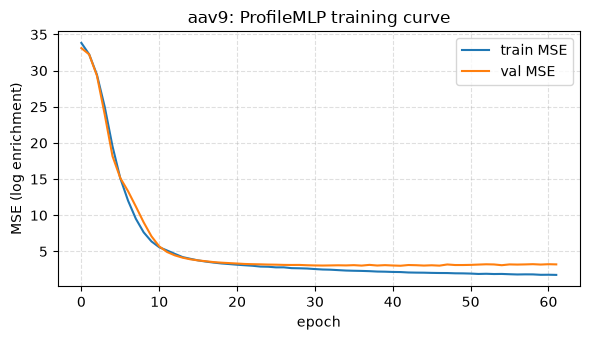

Held-out test set (34,388 variants): Pearson r(target, predicted) = 0.9133


In [10]:
seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix].reshape(len(df), -1)

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)
y_train_full, y_test = target[idx_train], target[idx_test]
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]
Xtr, ytr, Xva, yva    = split_train_val(X_train_full, y_train_full, val_frac=0.15, seed=0)

print(f"train: {len(Xtr):,}  val: {len(Xva):,}  test: {len(X_test):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr, ytr, Xva, yva, seed=0)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"], label="val MSE")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log enrichment)"); ax.set_title("aav9: ProfileMLP training curve")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout(); plt.show()

pred_test = np.asarray(predict_log_enrichment(model_mlp, jnp.asarray(X_test)))
r_test    = pearson(y_test, pred_test)
print(f"Held-out test set ({len(y_test):,} variants): Pearson r(target, predicted) = {r_test:.4f}")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This is a DIFFERENT, smaller pool than every section above: <code>top500_idx</code> is the top-500 by real <code>target</code> restricted to the HELD-OUT test split only (<code>idx_test</code>, 34,388 of the 68,776 <code>aav9.csv</code> rows -- the other half trained <code>model_mlp</code>). <code>pred_top500</code> is <code>model_mlp</code>'s prediction evaluated AT those exact same 500 held-out sequences (not the model's own top-ranked set -- see "Superposition" further below for that distinct population). Do not confuse this held-out top-500 with the full-68,776-pool top-500s from the sections above.
</div>

### Top-500 real held-out variants (by target) vs. what our model predicts for them

Restricted to the held-out test set only (`idx_test`) -- comparing on rows the model was trained
on would just measure memorization, not genuine prediction. `top500_idx` is the 500 real
held-out variants with the highest actual `target`; `pred_top500` is what `model_mlp` itself
predicts for those exact same sequences.


Within the real top-500 held-out variants: Pearson r(target, predicted) = -0.0117   (vs. r=0.9133 over the FULL held-out test set)
mean real target = 4.088   mean predicted   = 2.410


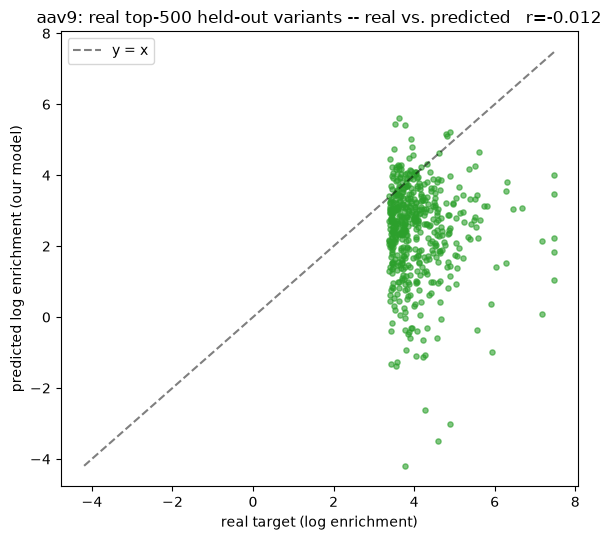

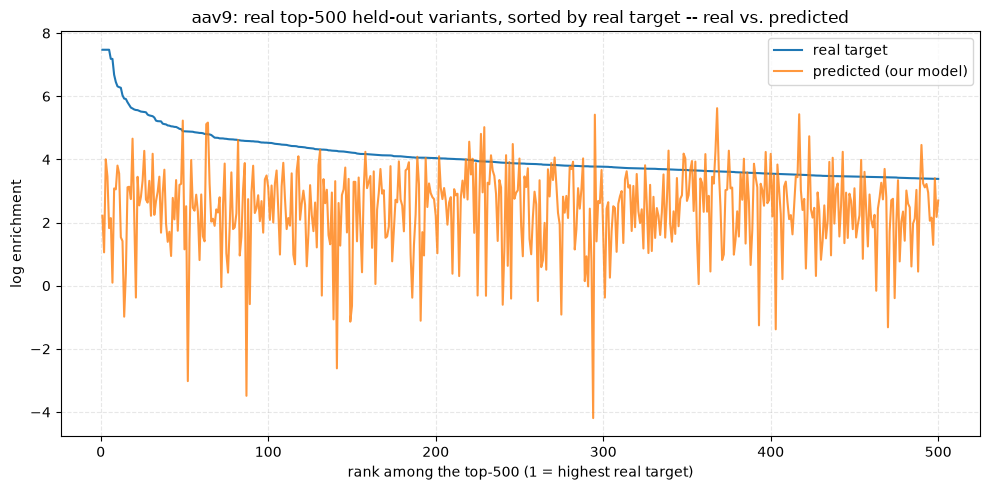

In [11]:
top500_idx  = np.argsort(-y_test)[:top_k]
real_top500 = y_test[top500_idx]
pred_top500 = pred_test[top500_idx]

r_top500 = pearson(real_top500, pred_top500)
print(f"Within the real top-{top_k} held-out variants: Pearson r(target, predicted) = {r_top500:.4f}   "
      f"(vs. r={r_test:.4f} over the FULL held-out test set)")
print(f"mean real target = {real_top500.mean():.3f}   mean predicted   = {pred_top500.mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(real_top500, pred_top500, s=14, alpha=0.6, color="tab:green")
lims = [min(real_top500.min(), pred_top500.min()), max(real_top500.max(), pred_top500.max())]
ax.plot(lims, lims, "k--", alpha=0.5, label="y = x")
ax.set_xlabel("real target (log enrichment)"); ax.set_ylabel("predicted log enrichment (our model)")
ax.set_title(f"aav9: real top-{top_k} held-out variants -- real vs. predicted   r={r_top500:.3f}")
ax.legend()
fig.tight_layout(); plt.show()

order = np.argsort(-real_top500)  # rank 1 = highest real target
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, top_k + 1), real_top500[order], color="tab:blue", label="real target")
ax.plot(np.arange(1, top_k + 1), pred_top500[order], color="tab:orange", alpha=0.8, label="predicted (our model)")
ax.set_xlabel(f"rank among the top-{top_k} (1 = highest real target)")
ax.set_ylabel("log enrichment")
ax.set_title(f"aav9: real top-{top_k} held-out variants, sorted by real target -- real vs. predicted")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout(); plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same held-out top-500 (<code>idx_test</code>, by real <code>target</code>, 34,388-row pool) as the section directly above. The random-500 baseline introduced in the next cell (<code>random500_idx</code>) is drawn from WITHIN <code>idx_test</code> only -- a different, smaller pool than the full-68,776 random-500 baseline used earlier in the "selection-bias diagnostics" section for <code>F_GT</code>/<code>J_naive</code>.
</div>

### Is this actually a problem? Checking whether the gap is model failure or selection bias from noisy `target`

Before concluding the model is "wrong", it's worth checking whether `target` itself is noisy
enough that the observed top-500 aren't reliably the true best 500 -- in which case failing to
match them exactly wouldn't be a real failure. Two direct ways to check that were tried first:

- `aav9.csv`'s `error` column: turns out to be a **constant `0.1` for all 68,776 rows** (std
  ~1e-17) -- it carries **no real per-variant information** in this file, so it can't be used to
  down-weight unreliable measurements.
- Duplicate sequences (repeated measurements of the same variant would let us estimate noise
  directly from their spread): there are **zero** duplicated sequences in `aav9.csv` -- every
  variant was measured exactly once.

So per-variant noise can't be measured directly here. What CAN be tested is the statistical
SIGNATURE that would explain the gap regardless of where the noise comes from (biological
replicate variance, PCR/sequencing noise, or anything else folded into `target`): if
`target = true_effect + noise`, selecting the top-500 by `target` selects for both a genuinely
high true effect AND a lucky positive noise draw. A well-calibrated model predicting the TRUE
effect will then systematically look "too low" for exactly this selected group -- even if it's
accurate everywhere else. This is the standard **regression-to-the-mean / "winner's curse"**
effect of selecting on a noisy proxy, and it makes two testable predictions:

1. A **random** sample of 500 test sequences (not selected on `target`) should NOT show the same
   collapse.
2. Across the WHOLE target range, the gap between real and predicted should grow smoothly toward
   BOTH extremes (the model should also over-estimate the worst variants) -- a symmetric
   "regression toward the mean" pattern, not something specific to the top.


In [12]:
rng = np.random.default_rng(0)
random500_idx  = rng.choice(len(y_test), size=top_k, replace=False)
real_random500 = y_test[random500_idx]
pred_random500 = pred_test[random500_idx]
r_random500    = pearson(real_random500, pred_random500)

print(f"Random {top_k} held-out variants (NOT selected on target): r={r_random500:.4f}   "
      f"mean real={real_random500.mean():.3f}   mean predicted={pred_random500.mean():.3f}")
print(f"Top-{top_k} held-out variants (selected on target):        r={r_top500:.4f}   "
      f"mean real={real_top500.mean():.3f}   mean predicted={pred_top500.mean():.3f}")


Random 500 held-out variants (NOT selected on target): r=0.9136   mean real=-4.153   mean predicted=-4.045
Top-500 held-out variants (selected on target):        r=-0.0117   mean real=4.088   mean predicted=2.410


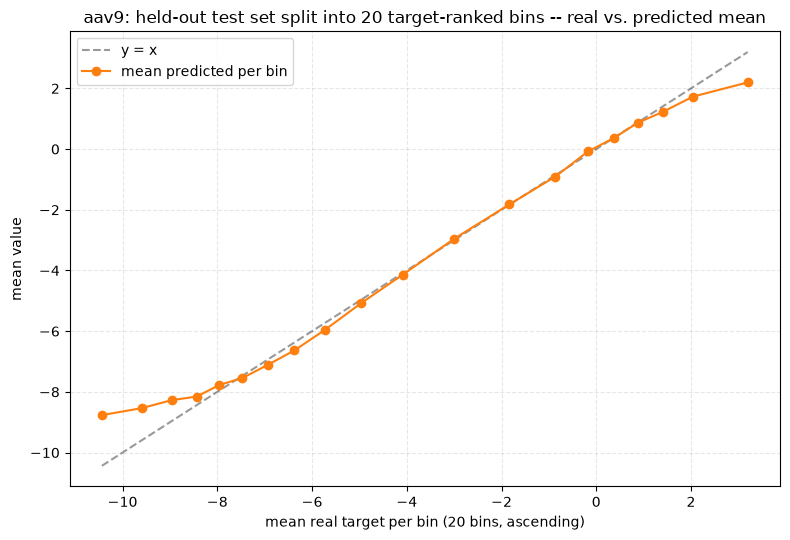

In [13]:
n_bins = 20
order       = np.argsort(y_test)
bins        = np.array_split(order, n_bins)
bin_real    = np.array([y_test[b].mean() for b in bins])
bin_pred    = np.array([pred_test[b].mean() for b in bins])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(bin_real, bin_real, "k--", alpha=0.4, label="y = x")
ax.plot(bin_real, bin_pred, "o-", color="tab:orange", label="mean predicted per bin")
ax.set_xlabel(f"mean real target per bin ({n_bins} bins, ascending)"); ax.set_ylabel("mean value")
ax.set_title(f"aav9: held-out test set split into {n_bins} target-ranked bins -- real vs. predicted mean")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout(); plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Recap -- FOUR top-500 sets are compared here, two per panel. LEFT panel: top-500 by real <code>target</code> vs. top-500 by <code>F_GT</code>/<code>J_naive</code> score, BOTH over the full 68,776-variant <code>aav9.csv</code> pool (same pair as the "Do the top-500 real variants..." section near the top of this notebook). RIGHT panel: top-500 by real <code>target</code> vs. top-500 by <code>model_mlp</code>'s OWN highest-predicted 500 (<code>top_pred_idx</code>), BOTH restricted to the 34,388-row HELD-OUT test split (<code>idx_test</code>) -- note <code>top_pred_idx</code> ("model's own top-500") is a new population here, distinct from the earlier <code>pred_top500</code> (which was the model's predicted values AT the real top-500's indices, not the model's own top-ranked set).
</div>

### Superposition of each top-500 set

Two direct overlap checks, both restricted to exactly `top_k` = 500 elements per set so the
diagrams are directly comparable:

- **Full dataset**: the 500 real variants with the highest `target`, vs. the 500 variants with
  the highest `F_GT`/`J_naive` score (both computed over all 68,776 real variants).
- **Held-out test set**: the 500 real variants with the highest `target`, vs. the 500 variants
  `model_mlp` itself would rank highest by its own prediction (both restricted to the 34,388
  held-out test variants -- the only fair comparison for a trained model).


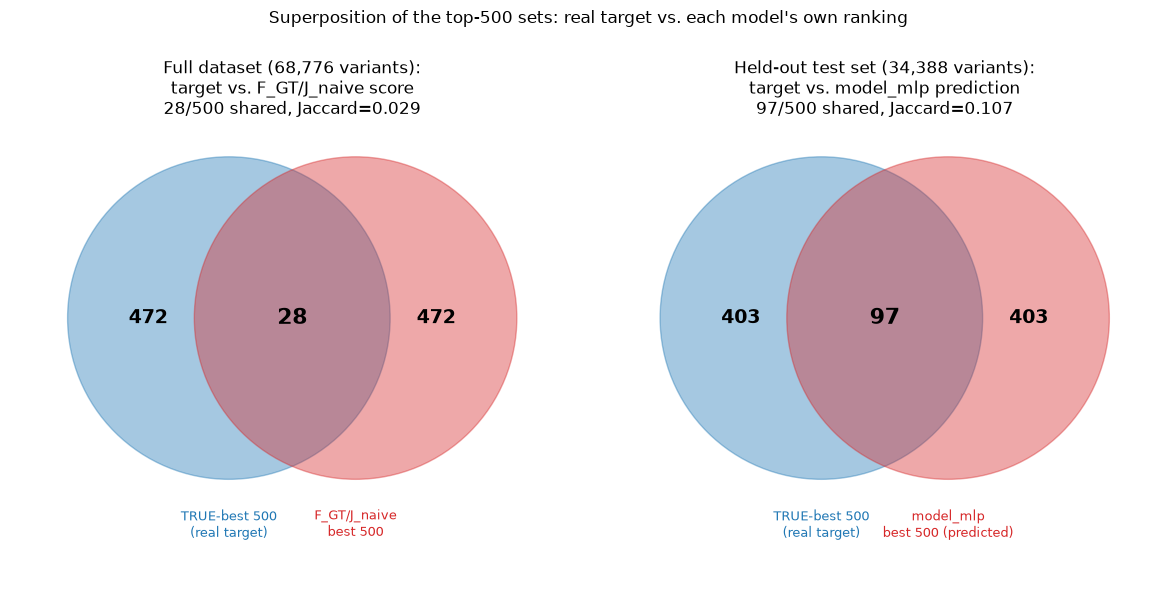

In [14]:
from matplotlib.patches import Circle


def top_k_overlap(y_true, y_pred, k):
    """Exact count of shared indices between the top-k by y_true and the top-k by y_pred."""
    return len(set(np.argsort(-y_true)[:k].tolist()) & set(np.argsort(-y_pred)[:k].tolist()))


def plot_top500_venn(set1, set2, label1, label2, name="", ax=None):
    """Manual two-circle Venn diagram (fixed-size circles, not area-proportional -- no
    matplotlib_venn dependency) showing the overlap between two top-k index sets, with exact
    counts labeled in each region."""
    shared   = set1 & set2
    n1_only  = len(set1) - len(shared)
    n2_only  = len(set2) - len(shared)
    n_shared = len(shared)
    jaccard  = n_shared / (n1_only + n2_only + n_shared)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    r, d = 1.4, 1.1
    ax.add_patch(Circle((-d / 2, 0), r, color="tab:blue", alpha=0.4))
    ax.add_patch(Circle(( d / 2, 0), r, color="tab:red",  alpha=0.4))
    ax.text(-d / 2 - 0.7, 0, f"{n1_only}", ha="center", va="center", fontsize=14, fontweight="bold")
    ax.text( d / 2 + 0.7, 0, f"{n2_only}", ha="center", va="center", fontsize=14, fontweight="bold")
    ax.text(0, 0, f"{n_shared}", ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(-d / 2, -r - 0.25, label1, ha="center", va="top", color="tab:blue", fontsize=9)
    ax.text( d / 2, -r - 0.25, label2, ha="center", va="top", color="tab:red", fontsize=9)
    ax.set_xlim(-d / 2 - r - 0.5, d / 2 + r + 0.5); ax.set_ylim(-r - 0.9, r + 0.3)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{name}\n{n_shared}/{top_k} shared, Jaccard={jaccard:.3f}")
    return ax


top_score_idx        = set(np.argsort(-gt_score)[:top_k].tolist())
top_target_full_idx  = set(top_target_idx.tolist())

top_pred_idx         = set(np.argsort(-pred_test)[:top_k].tolist())
top_target_test_idx  = set(top500_idx.tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_top500_venn(top_target_full_idx, top_score_idx,
                  "TRUE-best 500\n(real target)", "F_GT/J_naive\nbest 500",
                  name=f"Full dataset ({len(df):,} variants):\ntarget vs. F_GT/J_naive score", ax=axes[0])
plot_top500_venn(top_target_test_idx, top_pred_idx,
                  "TRUE-best 500\n(real target)", "model_mlp\nbest 500 (predicted)",
                  name=f"Held-out test set ({len(y_test):,} variants):\ntarget vs. model_mlp prediction", ax=axes[1])
fig.suptitle(f"Superposition of the top-{top_k} sets: real target vs. each model's own ranking")
fig.tight_layout(rect=[0, 0, 1, 0.88]); plt.show()


### Suggesting (and trying) a different loss function

`error` being a constant and there being zero duplicate sequences (previous section) rules out
the textbook fix of weighting the loss by measurement uncertainty -- there's no per-variant
noise signal available in this file to weight by. What we DO know is that **MSE is the wrong
objective for this specific goal**: it optimizes for accurate absolute values everywhere,
weighted equally across the whole range, with no special incentive to get the RELATIVE ORDER of
the extreme top variants right -- and under any noise (whatever its origin), the
MSE-minimizing prediction naturally shrinks toward the conditional mean for extreme points,
exactly the pattern shown above. Candidates that target the actual goal -- correctly ranking the
best candidates, not matching an exact possibly-noisy value -- directly instead:

- **Pairwise ranking loss (RankNet-style)** -- for every pair of sequences in a batch, penalize
  the model only if it gets their RELATIVE order wrong, regardless of the absolute gap. Tried
  below.
- **Asymmetric / pinball (quantile) loss at a high quantile (e.g. tau=0.9)** -- penalizes
  UNDER-estimating high targets more than over-estimating them, directly countering the
  systematic underprediction seen above, without needing pairs.
- **Top-k-focused ("top push") ranking loss** -- restrict the pairwise ranking loss to only pairs
  involving the top fraction of each batch, so the model spends its capacity on the extreme tail
  instead of the well-populated middle it already handles fine.
- **Heteroscedastic / inverse-variance-weighted MSE** -- the textbook fix when noise genuinely
  varies per example (weight by `1/error**2`) -- **not usable on this file** since `error`
  carries no real information here, but worth keeping in mind for a dataset with genuine
  per-variant uncertainty (e.g. read-count-derived).

Tried below: the pairwise ranking loss -- the most direct match for "get the best candidates
right", easy to implement, and it gives a clean before/after comparison against the existing
MSE-trained `model_mlp` on the exact same top-500 recovery metric used throughout this
notebook.



Training ProfileMLP (ranking loss):   0%|          | 0/300 [00:00<?, ?it/s]


Training ProfileMLP (ranking loss):   0%|          | 1/300 [00:01<07:05,  1.42s/it]


Training ProfileMLP (ranking loss):   1%|▏         | 4/300 [00:01<01:27,  3.37it/s]


Training ProfileMLP (ranking loss):   3%|▎         | 8/300 [00:01<00:39,  7.39it/s]


Training ProfileMLP (ranking loss):   4%|▎         | 11/300 [00:01<00:27, 10.50it/s]

...


Training ProfileMLP (ranking loss):  13%|█▎        | 38/300 [00:02<00:08, 29.11it/s]


Training ProfileMLP (ranking loss):  14%|█▍        | 42/300 [00:02<00:08, 29.90it/s]


Training ProfileMLP (ranking loss):  15%|█▌        | 46/300 [00:02<00:08, 30.02it/s]


Training ProfileMLP (ranking loss):  16%|█▌        | 47/300 [00:02<00:15, 16.04it/s]

Early stopping at epoch 47 (best val ranking loss=0.3132)


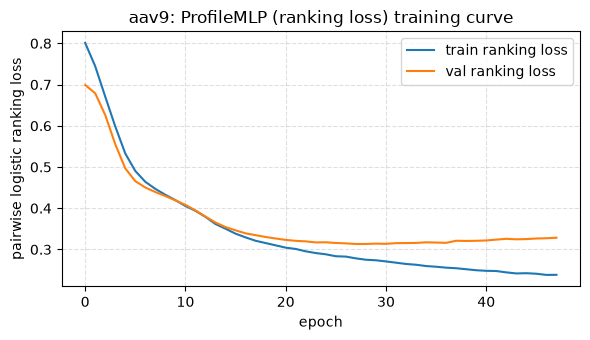

In [15]:
@nnx.jit
def train_step_rank(model, optimizer, x, y, rngs):
    """Pairwise logistic (RankNet-style) ranking loss over every pair in the batch: penalizes
    the model only if it gets a pair's RELATIVE order wrong, regardless of the absolute gap."""
    def loss_fn(model, rngs):
        y_pred    = model(x, train=True, rngs=rngs)
        diff_pred = y_pred[:, None] - y_pred[None, :]
        diff_true = y[:, None] - y[None, :]
        sign_true = jnp.sign(diff_true)
        mask      = 1.0 - jnp.eye(x.shape[0])
        pair_loss = jax.nn.softplus(-sign_true * diff_pred) * mask
        return jnp.sum(pair_loss) / jnp.sum(mask)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step_rank(model, x, y):
    y_pred    = model(x, train=False)
    diff_pred = y_pred[:, None] - y_pred[None, :]
    diff_true = y[:, None] - y[None, :]
    sign_true = jnp.sign(diff_true)
    mask      = 1.0 - jnp.eye(x.shape[0])
    pair_loss = jax.nn.softplus(-sign_true * diff_pred) * mask
    return jnp.sum(pair_loss) / jnp.sum(mask)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan_rank(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step_rank(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp_rank(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                            dropout_rate=0.1, epochs=300, batch_size=256,
                            peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                            patience=20, seed=0, verbose=True):
    """Same training loop as train_profile_mlp, but with the pairwise ranking loss above
    instead of MSE."""
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP (ranking loss)", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan_rank(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step_rank(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val ranking loss={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


model_rank, hist_rank = train_profile_mlp_rank(Xtr, ytr, Xva, yva, seed=0)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist_rank["train_loss"], label="train ranking loss")
ax.plot(hist_rank["val_loss"], label="val ranking loss")
ax.set_xlabel("epoch"); ax.set_ylabel("pairwise logistic ranking loss")
ax.set_title("aav9: ProfileMLP (ranking loss) training curve")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout(); plt.show()

pred_test_rank = np.asarray(predict_log_enrichment(model_rank, jnp.asarray(X_test)))


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
On the HELD-OUT test split only (<code>idx_test</code>, the same 34,388-row pool as the "Superposition" right panel and the "...vs. what our model predicts" section above) -- NOT the full 68,776-variant pool. Compares the TRUE top-500 (by real <code>y_test</code>) against each model's OWN top-500 (by its own highest-predicted values): <code>pred_test</code> for the MSE-trained <code>model_mlp</code>, <code>pred_test_rank</code> for the freshly-trained pairwise-ranking-loss model.
</div>

### Ranking-loss model vs. MSE-trained model: does it actually recover more of the true top-500?

Held-out test set -- Pearson r:            MSE-trained model=0.9133   ranking-loss model=0.9124
Own top-500 recovers the TRUE top-500:  MSE-trained model=97/500   ranking-loss model=100/500


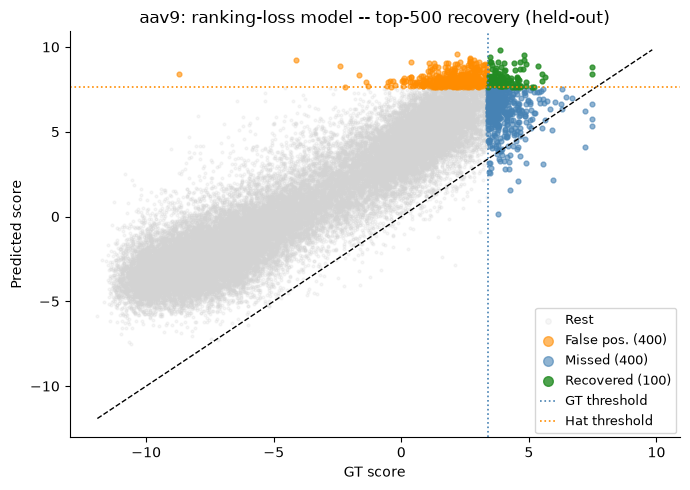

In [16]:
n_mse  = top_k_overlap(y_test, pred_test,      top_k)
n_rank = top_k_overlap(y_test, pred_test_rank, top_k)
r_test_rank = pearson(y_test, pred_test_rank)

print(f"Held-out test set -- Pearson r:            MSE-trained model={r_test:.4f}   ranking-loss model={r_test_rank:.4f}")
print(f"Own top-{top_k} recovers the TRUE top-{top_k}:  MSE-trained model={n_mse}/{top_k}   ranking-loss model={n_rank}/{top_k}")

k_frac_test = top_k / len(y_test)
plot_topk_recovery(y_test, pred_test_rank, k_frac=k_frac_test,
                    title=f"aav9: ranking-loss model -- top-{top_k} recovery (held-out)")
plt.show()
